## __More Ensemble Models__

Ensembles are the combination of different machine learning models, where by averaging the results of all models trained together on the same dataset, the result can be away good than any individual model. These types of models can be used for all kinds of tasks, including classification, regression and detecting anomalies.\
"Suppose you pose a complex question to thousands of random people, then aggregate their answers. In many cases you will find that this aggregated answer is better than an expert’s answer. This is called the wisdom of the crowd. Similarly, if you aggregate the predictions of a group of predictors (such as classifiers or regressors), you will often get better predictions than with the best individual predictor. A group of predictors is called an ensemble; thus, this technique is called Ensemble Learning, and an Ensemble Learning algorithm is called an Ensemble method."

Random Forests that was used in the previous notebook is an example of ensemble models. It combined different decision trees. Usually, these types of models are classified into three groups that will be covered in this notebook:

* Averaging Methods: Such as voting classifiers/regressors, bagging classifiers/regressors, random forests, extra trees classifier/regressor, etc...
* Boosting Methods: Gradient Boosting, AdaBoost, XGBoost
* Stacking in which instead of averaging the results of multiple models, multiple models are trained on the full training set and there is a final model trained on the different subsets (folds) of the training set.\
Most of the above algorithms are implemented in Sklearn, except XGBoost and Stacking which is implemented indirectly.

These types of models can be used for both regression and classification, but I'll consider classification domain and for giving focus on the ensemble models, we will use the same dataset we used previouly, in random forests.

### __Ensemble Methods for Classification__

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

In [3]:
from sklearn.datasets import fetch_openml

elec_data=fetch_openml(name='electricity',version=1)

In [4]:
type(elec_data),(elec_data.details)

(sklearn.utils._bunch.Bunch,
 {'id': '151',
  'name': 'electricity',
  'version': '1',
  'description_version': '1',
  'format': 'ARFF',
  'creator': ['M. Harries', 'J. Gama', 'A. Bifet'],
  'collection_date': '1998-12-05',
  'upload_date': '2014-04-10T02:42:23',
  'language': 'English',
  'licence': 'Public',
  'url': 'https://api.openml.org/data/v1/download/2419/electricity.arff',
  'parquet_url': 'https://data.openml.org/datasets/0000/0151/dataset_151.pq',
  'file_id': '2419',
  'default_target_attribute': 'class',
  'version_label': '1',
  'tag': ['AzurePilot',
   'concept_drift',
   'Data Science',
   'Economics',
   'electricity',
   'Kaggle',
   'mythbusting_1',
   'OpenML-CC18',
   'OpenML100',
   'study_1',
   'study_123',
   'study_135',
   'study_14',
   'study_15',
   'study_16',
   'study_20',
   'study_34',
   'study_37',
   'study_41',
   'study_7',
   'study_70',
   'study_99',
   'Sustainability'],
  'visibility': 'public',
  'original_data_url': 'http://www.inescporto

In [5]:
elec_data.data.shape,elec_data.feature_names, elec_data.target_names

((45312, 8),
 ['date',
  'day',
  'period',
  'nswprice',
  'nswdemand',
  'vicprice',
  'vicdemand',
  'transfer'],
 ['class'])

In [6]:
elec_df=elec_data.frame
type(elec_df)

pandas.core.frame.DataFrame

### __EDA__

In [7]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(elec_df,test_size=0.25,random_state=20)
print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 33984 
The size of testing data is: 11328


In [8]:
train_data.head(10)

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
27325,0.469846,4,0.276596,0.164705,0.519637,0.011417,0.657949,0.265789,DOWN
28731,0.474227,5,0.574468,0.024919,0.191907,0.001656,0.090886,0.819737,DOWN
8450,0.023141,3,0.042553,0.065270,0.250074,0.003467,0.422915,0.414912,DOWN
36659,0.889385,2,0.744681,0.148193,0.670039,0.009981,0.533402,0.563596,UP
781,0.000708,4,0.276596,0.124204,0.475454,0.003467,0.422915,0.414912,UP
13013,0.428963,7,0.106383,0.055242,0.084647,0.003467,0.422915,0.414912,DOWN
3330,0.009203,1,0.382979,0.045635,0.741892,0.003467,0.422915,0.414912,DOWN
18851,0.446662,2,0.744681,0.183409,0.785034,0.012154,0.757639,0.517105,UP
14838,0.433830,3,0.127660,0.047886,0.141476,0.003467,0.422915,0.414912,DOWN
30462,0.868236,6,0.638298,0.030833,0.702023,0.001963,0.538322,0.674123,UP


In [9]:
train_data.tail(10)

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer,class
8744,0.026459,2,0.170213,0.047526,0.157989,0.003467,0.422915,0.414912,DOWN
15328,0.434273,6,0.340426,0.060736,0.427105,0.003467,0.422915,0.414912,DOWN
1607,0.004513,7,0.489362,0.043953,0.391104,0.003467,0.422915,0.414912,DOWN
22294,0.455998,4,0.468085,0.075838,0.594763,0.005168,0.623511,0.356579,UP
3915,0.009734,6,0.574468,0.081062,0.516067,0.003467,0.422915,0.414912,UP
31962,0.875846,2,0.893617,0.028822,0.427998,0.001288,0.385293,0.813158,DOWN
23452,0.460112,7,0.595745,0.026660,0.369979,0.001774,0.234076,0.621053,DOWN
23775,0.460422,7,0.319149,0.026750,0.373550,0.001813,0.269032,0.564035,DOWN
37135,0.889828,5,0.659574,0.028462,0.555638,0.002021,0.625583,0.248684,DOWN
27098,0.469625,6,0.553191,0.054792,0.514430,0.003712,0.545572,0.229825,UP


__Two things to draw from the dataset for now:__

* The target feature class is categorical. We will make sure to encode that during data preprocessing.
* All numerical features are already normalized, so we won't need to normalize these type of features.

### Checking Summary Statistics

In [10]:
train_data.describe()

,date,period,nswprice,nswdemand,vicprice,vicdemand,transfer
count,33984.000000,33984.000000,33984.000000,33984.000000,33984.000000,33984.000000,33984.000000
mean,0.498150,0.499211,0.057922,0.424763,0.003445,0.423035,0.500089
std,0.340429,0.294571,0.040195,0.163858,0.008846,0.121087,0.153224
min,0.000000,0.000000,0.000000,0.001190,0.000000,0.000000,0.000000
25%,0.031857,0.234043,0.035247,0.307944,0.002283,0.372087,0.414912
50%,0.456307,0.489362,0.048667,0.442725,0.003467,0.422915,0.414912
75%,0.880581,0.744681,0.074276,0.535704,0.003467,0.469446,0.605263
max,1.000000,1.000000,0.981806,1.000000,1.000000,1.000000,1.000000


In [11]:
train_data.isnull().sum()

date         0
day          0
period       0
nswprice     0
nswdemand    0
vicprice     0
vicdemand    0
transfer     0
class        0
dtype: int64

### __Checking Correlation__

In [12]:
# corr=train_data.corr() -this will fail as train_data has categorical feature presence
X_train=train_data.drop('class',axis=1)
y_train=train_data['class']

corr=X_train.corr()
corr
# X_train.columns

,date,day,period,nswprice,nswdemand,vicprice,vicdemand,transfer
date,1.000000,0.003798,0.001093,-0.147831,0.071211,0.005025,0.054869,0.403891
day,0.003798,1.000000,0.001450,0.007767,-0.050796,0.002652,0.080768,-0.058719
period,0.001093,0.001450,1.000000,0.105756,0.448519,0.026932,0.197971,-0.123107
nswprice,-0.147831,0.007767,0.105756,1.000000,0.303089,0.302866,0.300144,-0.270199
nswdemand,0.071211,-0.050796,0.448519,0.303089,1.000000,0.094830,0.670707,-0.269233
vicprice,0.005025,0.002652,0.026932,0.302866,0.094830,1.000000,0.139523,-0.094884
vicdemand,0.054869,0.080768,0.197971,0.300144,0.670707,0.139523,1.000000,-0.555772
transfer,0.403891,-0.058719,-0.123107,-0.270199,-0.269233,-0.094884,-0.555772,1.000000


<Axes: >

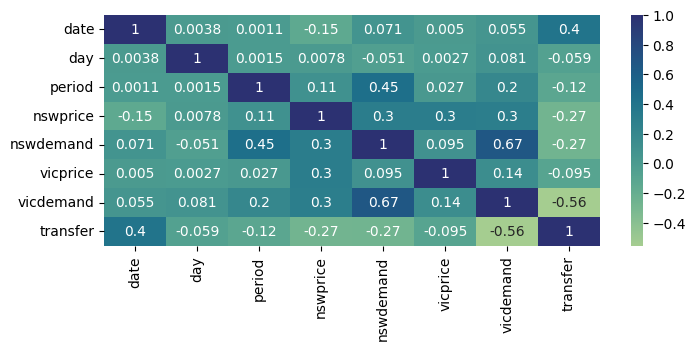

In [13]:
plt.figure(figsize=(8,3))
sns.heatmap(data=corr,annot=True, cmap='crest')

### few more data Exploration

<Axes: xlabel='class', ylabel='count'>

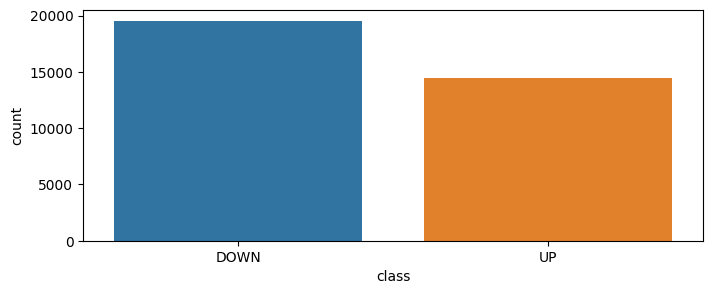

In [14]:
plt.figure(figsize=(8,3))
sns.countplot(data=train_data,x='class',hue='class')

`Day` is the days of the week, from `1-7`, Monday to Sunday. Let's count the days occurences in respect to the `ups/downs` of the electricity's price

<Axes: xlabel='day', ylabel='count'>

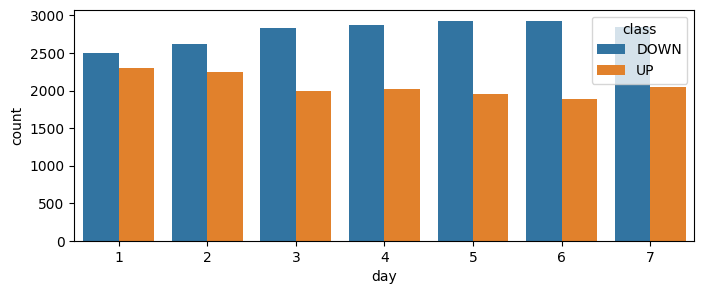

In [15]:
plt.figure(figsize=(8,3))
sns.countplot(data=train_data,x='day',hue='class')

It seems that most days had downs. From the beginning of the week, there were consistent increase in downs(price of electricity went down) and decrease in ups. I am thinking: If we talk to somoene who stays in South Wales, maybe our analysis can make sense.

Let's see if there is an appealing relationship between the `demand/price` of electricity in New South Wales and Victoria.

<Axes: xlabel='vicdemand', ylabel='nswdemand'>

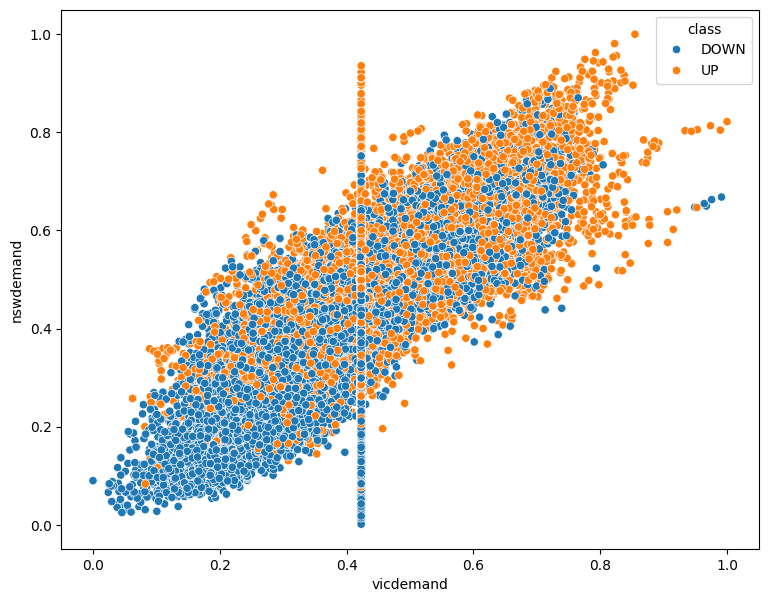

In [16]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=train_data, x='vicdemand', y='nswdemand', hue='class')

<Axes: xlabel='vicdemand', ylabel='nswdemand'>

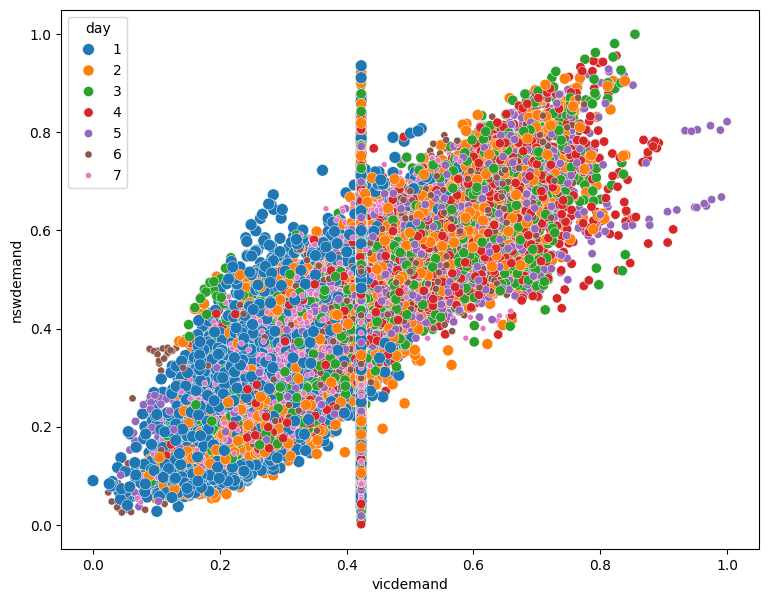

In [17]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=train_data, x='vicdemand', y='nswdemand', hue='day', size='day')

Although it is kind of hard to draw a strong point, there is less demand of electricity in both cities on Monday and Sunday than other days. We can use a line plot to plot the demand in both cities on the course of the days.

<Axes: xlabel='day', ylabel='nswdemand'>

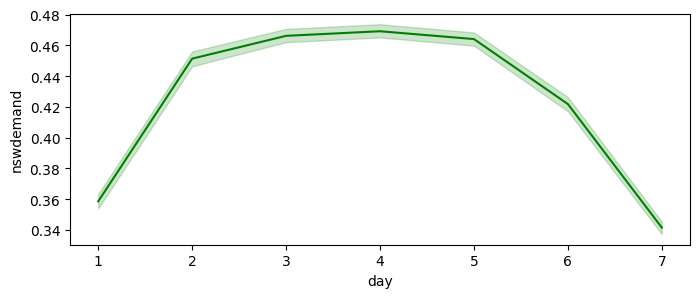

In [18]:
plt.figure(figsize=(8,3))
sns.lineplot(data=train_data, x='day', y='nswdemand', color='green')

<Axes: xlabel='day', ylabel='vicdemand'>

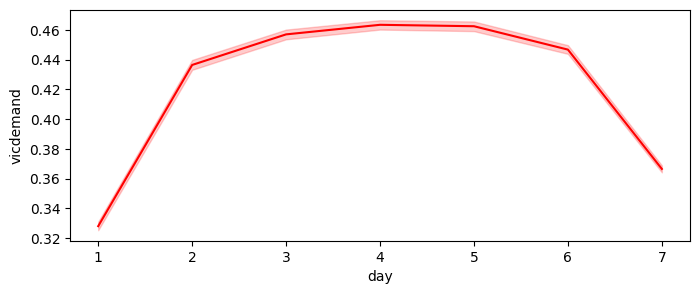

In [19]:
plt.figure(figsize=(8,3))
sns.lineplot(data=train_data, x='day', y='vicdemand', color='red')

Another interesting thing to look in the dataset is if there are some seasonalities/trends in the demand/price in either Victoria or New South Wales over period of time. In time series analysis, seasonality is when there is repetitive scenarios or consistent behaviours over the course of time. Take a different example: It has been observed that the shopping sites experience a consistent increase of page visitors at weekends. That type of example is seasonal: it always happens and in the same way, same amount, and same period.

On the other hand, the trend is a prolonged increase/decrease in a given attribute. A classic example of this is Moore's law which predicted that the number of transistors will double every two years, and that has happened 100% for so long, last 50 years or so. Moore's law were backed by the advent of microprocessors and the need of computation power. That is a trend.

In the real-life, you can have trends mixed with seasonalities. And sometimes noise can come into the picture.

I wanted to go deep to explain these time series terms, but le's come back to our analysis. If you look at the demand of the electricity in both cities on the course of date (`7 May 1996 to 5 December 1998`), you can see that there are some types of seasonalities. Not 100% but it seems there is and if this dataset would have been collected for more than two years, it would probably be easy to know surely if there are seasonalities.

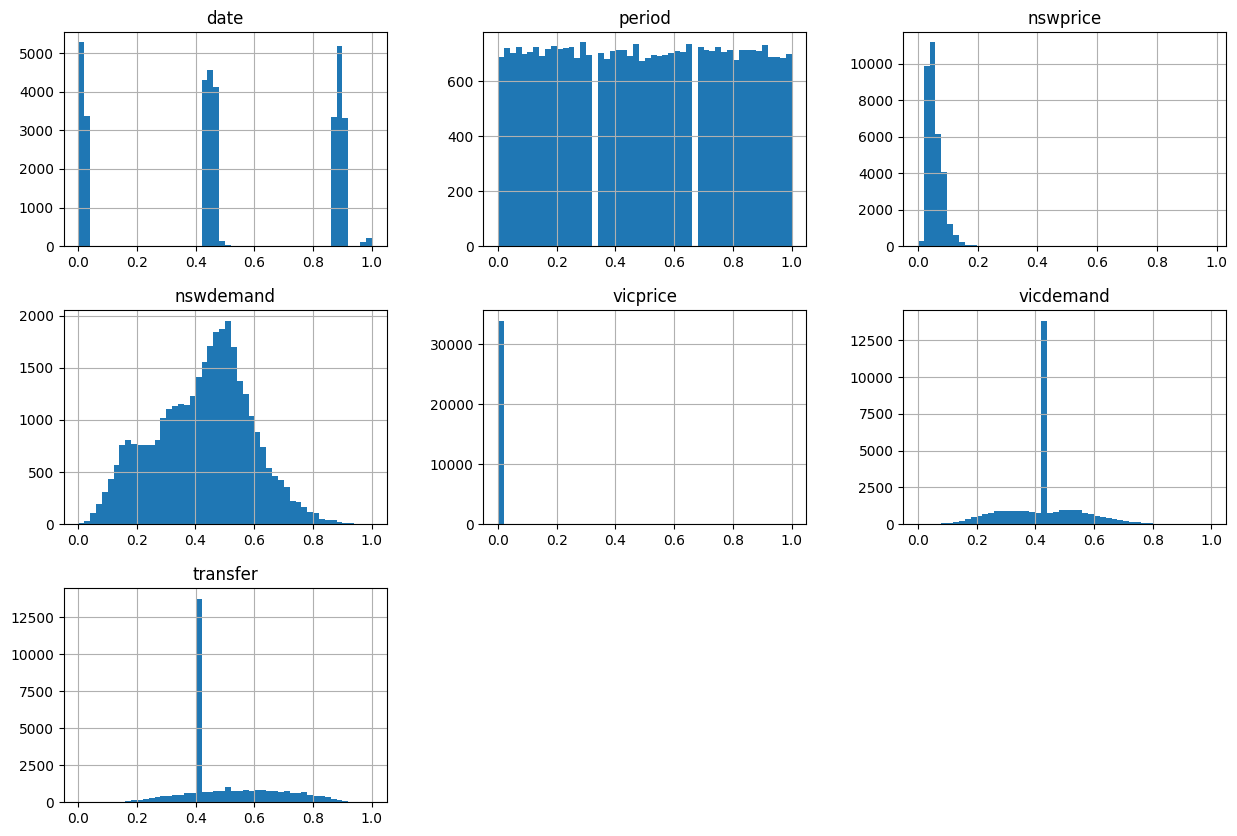

In [20]:
train_data.hist(bins=50, figsize=(15,10))
plt.show()

## __Data Preprocessing__

Let's encode the categorical feature `class`.

In [21]:
from sklearn.preprocessing import LabelEncoder

label_enc=LabelEncoder()
y_train_prepared=label_enc.fit_transform(y_train)
y_train_prepared

array([0, 0, 0, ..., 0, 0, 1], shape=(33984,))

But again if you look at the dat, the `day` feature is not normalized as other features. We can normalize it or leave it but for now let's go ahead and train the random forests classifier

## __Training Ensemble Classifiers__

#### __Voting Classifier__

Let's assume that you have trained 3 different classifiers on the training data but none of these classifiers had an oustanding results.

The idea of Voting ensemble technique is fairly simple. We can aggregate the results of all those 3 classifiers and the result will be good than any single classifier.

Let's train 3 classifiers on the training data and then we will go ahead and aggregate their results.

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score

log_classifier =  LogisticRegression()
sv_classifier = SVC()
sgd_classifier = SGDClassifier()

def classifiers(clf1, clf2, clf3, X_train, y_train):
    # A list of all classifiers
    clfs = [clf1, clf2, clf3]
    
    # An empty list to comprehend 
    all_clfs_acc = []
    
    # Train each classifier, evaluate it on the training set 
    # And append the accuracy as list
    
    for clf in clfs:
        print(f'Executing {clf} model')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_train)
        # print(preds)
        acc = accuracy_score(y_train,preds)
        # acc = acc.tolist()
        all_clfs_acc.append(acc)
        
    return all_clfs_acc


In [24]:
classifiers(log_classifier, sv_classifier, sgd_classifier, X_train_scaled, y_train_prepared)

Executing LogisticRegression() model
Executing SVC() model
Executing SGDClassifier() model


[0.7512653013182674, 0.7908427495291902, 0.7548258003766478]

As you can see, the function returned 4 accuracies on the training set. The first accuracy correspond to Logistic Regression, the second is Support Vector Classifier, and the third is SGD(Stockastic Gradient Descent,

Now, let us use Voting Classifier to aggregate the results of all of those 3 classifiers.

In [25]:
from sklearn.ensemble import VotingClassifier

vot_classifier = VotingClassifier(
    estimators=[('log_reg', log_classifier),
                ('svc', sv_classifier),
                ('sgd', sgd_classifier)], 
    voting='hard')

vot_classifier.fit(X_train_scaled, y_train_prepared)

,estimators,"[('log_reg', ...), ('svc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


Since we will need to calculate accuracy often, let's make a function to be calling always.

In [26]:
from sklearn.metrics import accuracy_score

def accuracy(model, data, labels):
    
    predictions = model.predict(data)
    acc = accuracy_score(labels, predictions)
    
    return acc

In [27]:
accuracy(vot_classifier, X_train_scaled, y_train_prepared)

0.7603283898305084

As we can see, it slightly outperformed all individual classifiers. It's small increments in the accuracy but most of the time, it will be always better than any individual classifier.

Let's change something.

If you can go back where we defined the Voting classifier, the voting hyperparameter is hard and what that means is that it uses the predicted class labels for majority rule voting. Let's change it to soft. Doing so will average the class with highest probabilities on all individual classifiers.

Since SVC doesn't support predicting class probabilities by default, let's set it to True. When I tried to find the accuracy score, it returned an error (there is a note on documentation that it doesn't work with predict method) but if you include a model which supports probability scores, it will work well without an error.

In [28]:
# sv_classifier = SVC(probability=True)

# vot_classifier = VotingClassifier(
    
#     estimators=[('log_reg', log_classifier),
#                 ('svc', sv_classifier),
#                 ('sgd', sgd_classifier)], 
#     voting='soft')

# vot_classifier.fit(X_train, y_train_prepared)

In [29]:
# accuracy(vot_classifier, X_train, y_train_prepared)

### __Bagging Classifier__

Instead of training different algorithms on the same data and average their results as Voting does, Bagging ensemble method train a single or multiple classifier/regressors on different subsets of the training data and aggregate the results on all subsets.

When this is used with complex models (that overfit data easily) like decision trees, the overfitting can be reduced.

Let's use bagging to train 500 decision trees on different subsets of data and then average the predictions on those subsets.

By setting `max_samples=0.5`, `max_features=0.5`, `bootstrap=False`, we are using random subsets of 50% of training data and random 50% subsets of features. If bootstrap is `True`, ratio of those training samples are sampled from the training data with replacement and if it is False, there is no replecement. When in fact bootstrap is `False`, this is called Pasting. There are also other techniques called Random Subspaces and Random Patches and they are all based off how the samples are drawn from the data. Learn more about these techniques and more about other hyperparameters on the [Scikit-Learn documentation](https://scikit-learn.org/stable/modules/ensemble.html#bagging).

One of the great way to improve a particular machine learning model is to learn about its hyperparameters and what each and each stands for. So, learn more about Bagging [here](https://scikit-learn.org/stable/modules/ensemble.html#id2).

In [30]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_classifier = BaggingClassifier(
      DecisionTreeClassifier(class_weight='balanced'),
    max_samples=0.5, max_features=0.5, bootstrap=False
)

bag_classifier.fit(X_train_scaled, y_train_prepared)

,estimator,DecisionTreeC...ht='balanced')
,n_estimators,10
,max_samples,0.5
,max_features,0.5
,bootstrap,False
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [32]:
accuracy(bag_classifier, X_train_scaled, y_train_prepared)

0.9817266949152542

Wow, this is much better. Bagging ensembles work well and they outperform Voting ensembles. Other remarkable thing about them is that they are able to overcome the overfitting especially when used with decision trees (decision trees tend to overfit easily). Let's now see other type of ensemble models: Gradient Boosting Classifier.

### __Gradient Boosting Classifier__

Gradient boosting works like bagging methods. The only difference is that instead of training models on subsets of training data, models(decision trees) are trained in a sequence where each tree model takes the error of the previous tree to correct it and the sequence goes on...

Simply, the initial model is trained on the full data, but then the next models minimizes the previous errors.

Just like other models, gradient boosting classifier has hyperparameters but the most important ones are number of estimators or trees (`n_estimators`) and learning rate (`learning_rate`)

In [37]:
from sklearn.ensemble import GradientBoostingClassifier

grad_boost_clf = GradientBoostingClassifier(
                        n_estimators=500, 
                        learning_rate=0.8, 
                        random_state=42,
                        max_depth=2)

grad_boost_clf.fit(X_train_scaled, y_train_prepared)

,loss,'log_loss'
,learning_rate,0.8
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [38]:
accuracy(grad_boost_clf, X_train_scaled, y_train_prepared)

0.9269362052730696

One disadvantage of the Gradient Boosting ensemble method is that it is easy to overfit, and that has to do with how they works. By minimizing the errors consecutively (tree after tree), they can be so perfect but the ofcourse won't be perfect when fed to the test data.

One way to avoid overfitting is to carefully choose the learning rate that scale well with the number of estimators. Although the high number of estimators can't necessarily cause overfitting (gradient boosting is a robust model), the learning rate has to be low. In other words, there is a trade off between these two hyperparameters. The higher the learning rate, the lower estimators and vice versa. If you can get a good results with low learning rate, there is a chance that it will generalize well on test too.

I have spent sometime changing these two parameters and trying to see their effects and that what I was able to observe. You can try that too!

For classification problems beyond two classes, Scikit-Learn recommend using [Histogram Gradient Boosting Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html#sklearn.ensemble.HistGradientBoostingClassifier) which is a faster version of the Gradient Boosting Classifier. It is inspired by [Microsoft Light Gradient Boosting Machine (LightGBM)](https://github.com/Microsoft/LightGBM). LightGBM is fater, low memory usage, better performance, support distributed training and GPU, and can handle large datasets.

### __AdaBoost Classifier__

AdaBoost is another ensemble model in class of boosting methods. It's very much like gradient boost but instead of minimizing the error of the consecutive models, it updates the weights.

So, the first model (decision tree) is trained on the full training data, the next model weights are updated based off the previous weights and so forth.

The main parameters to tune to make AdaBoost work well are number of estimators and the maximum depth of each estimator.

In [40]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adaboost_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced'), 
    #base estimator is decision trees by default
    n_estimators=300,
    learning_rate=0.5

)

adaboost_clf.fit(X_train_scaled, y_train_prepared)

,estimator,"DecisionTreeC..., max_depth=3)"
,n_estimators,300
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,None
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [41]:
accuracy(adaboost_clf, X_train_scaled, y_train_prepared)

0.7966395951035782

Again, you can tune the number of estimators and the depth of the base estimator. The base estimator is Decision Trees by default.

### __Stacking Classifier__
Also referred to as Stacked Generalization, it is an ensemble method employed to reduce the biases and the errors rate made by multiple predictors(individual models/estimators).

Instead of averaging the predictions made by individual models or predictors, in stacking, multiple models are trained on the full training data and then the final model that is trained on different subsets of the training data takes the predictions of the former models and find the final predictions.

It is noted that it can be seen as the sophisticated version of the cross validation (per the reason why the final estimator is trained on the subsets or folds of the training data).

In [42]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


base_estimators = [
    ('rand', RandomForestClassifier(random_state=42)),
    ('svc', SVC(random_state=42))]

final_estimator = LogisticRegression()

stack_clf = StackingClassifier(estimators = base_estimators, 
                               final_estimator = final_estimator)

stack_clf.fit(X_train_scaled, y_train_prepared)

,estimators,"[('rand', ...), ('svc', ...)]"
,final_estimator,LogisticRegression()
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [43]:
accuracy(stack_clf, X_train_scaled, y_train_prepared)

1.0

Ohh the accuracy looks appealing! But is it really?. It might be that we overfitted the training data.

XGBoost
XGBoost standing for eXtreme Gradient Boosting is a an optimized version of the Gradient Boosting. I moved it down the other boosting methods per the reason that it is not implemented in Scikit-Learn.

XGBoost is faster, simple (like Scikit-Learn) and can solve many machine learning problems.

XGBoost can be installed like other libraries, just by `pip install xgboost`.

    import xgboost as xgb
    xgb_clf = xgb.XGBClassifier()
    xgb_clf.fit(X_train, y_train_prepared)

Refer, [Documentation](https://xgboost.readthedocs.io/en/latest/)

### __Evaluating the Ensemble Model on the Test Set__
Let's say that all we have been doing was trying to find an ensemble model that can fit well the data and so we want to test it on the test set before shipping it into production.

To narrow the choice down, I will use A Gradient Boosting method.

As always, I will prepare the test set in the same way that I prepared the training set. 

In [44]:
X_test = test_data.drop('class', axis=1)
y_test = test_data['class']

X_test_scaled=scaler.fit_transform(X_test)
y_test_prepared = label_enc.transform(y_test)

In [48]:
accuracy(grad_boost_clf, X_test_scaled, y_test_prepared)

0.8903601694915254

That's not really bad considering that the model never saw the test data anywhere in previous steps. The Gradient boosting method had ~92%.

Also remember that the function `accuracy` takes the model, training data,labels and return the accuracy. You can see that here:

    from sklearn.metrics import accuracy_score
    
    def accuracy(model, data, labels):    
        predictions = model.predict(data)
        acc = accuracy_score(labels, predictions)
        return acc
    
Let's also evaluate the stacking classifier. It was overly optimistic on the training data.

In [49]:
accuracy(stack_clf, X_test_scaled, y_test_prepared)

0.8859463276836158

Let's try bag classifier also, It had nearly 98% on the training data.

In [50]:
accuracy(bag_classifier, X_test_scaled, y_test_prepared)

0.8684675141242938

As we can see, all of the ensembles are not generalizing well on the test set. It's not that bad again, but there is a room of improvement. One sure way to improve the results of machine learning model is to improve the data.

You may also have to tune the hyperparamaters of the particular ensemble method and this works sometime too.